## **Setup**

In [15]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [16]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [17]:
import os
import gc
import optuna
import pandas as pd
import numpy as np
from xgboost import XGBRanker, plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import load_holdout_split, XGBOOST_DATAFRAMES
from Challenge.utils import evaluate_recommender_xgboost
from Challenge.XGBoostReranker import XGBoostRerankerRecommender, ProgressCallback
from Challenge.hyper_tuning import ModelOptimizer

## **Load Data**

In [18]:
np.random.seed(0xdead)
N_USERS_TO_SAMPLE = 6000

In [19]:
_, URM_outer = load_holdout_split()

In [20]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_OOF.parquet")

X_train_full = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_train_full

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/training_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,Label,EASE_R_Score,EASE_R_RankPosition,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,13,0,0,0,0,0,0,0.146634,106,...,2.763314,646,539,59,0.084832,0.081167,0.221003,77,413,1541.376587
1,0,5706,0,0,0,1,1,0,0.180238,58,...,2.756729,827,1427,10,0.191343,0.202138,0.577017,72,485,1429.055542
2,0,5766,0,0,1,1,1,0,0.305060,16,...,2.756729,351,1050,16,0.273811,0.139576,0.503647,72,2895,1429.055542
3,0,5830,0,0,0,0,0,0,0.162575,75,...,2.777495,412,1056,20,0.230950,0.167745,0.525276,72,1731,1429.055542
4,0,5956,0,0,0,0,0,0,0.241022,31,...,2.803360,43,47,10,0.289829,0.098583,0.472416,72,1454,1429.055542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23176689,27094,640,0,0,0,1,1,0,0.275289,76,...,4.523964,84,51,17,0.359248,0.152304,0.757386,221,2377,874.778259
23176690,27094,797,0,0,0,0,0,0,0.247680,96,...,4.458327,214,356,19,0.349893,0.228300,0.704917,221,615,874.778259
23176691,27094,868,0,0,0,0,0,0,0.316601,55,...,4.585932,706,1181,48,0.239673,0.137379,0.441403,221,6416,874.778259
23176692,27094,101,0,0,0,0,0,0,0.396964,33,...,4.503058,67,64,7,0.413890,0.196016,0.665027,221,576,818.176453


In [21]:
if not X_train_full['UserID'].is_monotonic_increasing:
    print("⚠️ Data is NOT sorted by UserID.")
    print("Sorting and overwriting file for future efficiency...")
    
    # Sort and reset index (critical for contiguous memory in ML)
    X_train_full = X_train_full.sort_values(by='UserID').reset_index(drop=True)
    
    # Overwrite the file on disk
    X_train_full.to_parquet(
        path=file_path,
        engine='fastparquet',
        compression='snappy',
        index=False
    )
    
    print(f"✅ Data sorted and saved to {file_path}")

In [22]:
# Get all unique users
all_unique_users = X_train_full['UserID'].unique()

# Pick 3,000 random users
# We sort them so the resulting matrices remain in ID order (0, 5, 10...) 
# rather than random order (10, 0, 5...). This prevents confusion later.
selected_users = np.sort(np.random.choice(all_unique_users, size=N_USERS_TO_SAMPLE, replace=False))

print(f"Subsampling: Selected {len(selected_users)} users out of {len(all_unique_users)}")

# Filter the DataFrame to keep ONLY these users
X_train_sub = X_train_full[X_train_full['UserID'].isin(selected_users)].copy()

# CRITICAL: Re-sort by UserID and ItemID so groups remain contiguous
X_train_sub = X_train_sub.sort_values(by=['UserID', 'ItemID']).reset_index(drop=True)

print(f"Data reduced from {len(X_train_full)} rows to {len(X_train_sub)} rows.")

Subsampling: Selected 6000 users out of 27095
Data reduced from 23176694 rows to 5132374 rows.


In [23]:
# -------------------------------------------------------------------------
# 4. Prepare XGBoost Inputs on the SUBSET
# -------------------------------------------------------------------------

assert X_train_sub['UserID'].is_monotonic_increasing, "Training set is not sorted by UserID!"

# Group Calculation (Must be done on the subset)
groups = X_train_sub.groupby("UserID").size().values

# Target
y_train = X_train_sub["Label"]

# Drop metadata to create Feature Matrix
X_train = X_train_sub.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')

# Categorical handling
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')

assert groups.sum() == X_train.shape[0], "Group sum mismatch!"

In [24]:
# Clear memory
del X_train_full, X_train_sub, all_unique_users
gc.collect()

0

In [25]:
X_train.columns

Index(['top_10', 'top_20', 'top_30', 'top_40', 'top_50', 'EASE_R_Score',
       'EASE_R_RankPosition', 'SLIMElasticNet_Score',
       'SLIMElasticNet_RankPosition', 'MultVAE_Score', 'MultVAE_RankPosition',
       'MatrixFactorization_WARP_Score',
       'MatrixFactorization_WARP_RankPosition', 'IALS_Score',
       'IALS_RankPosition', 'RP3beta_Score', 'RP3beta_RankPosition',
       'P3alpha_Score', 'P3alpha_RankPosition', 'UserKNN_cosine_Score',
       'UserKNN_cosine_RankPosition', 'UserKNN_tversky_Score',
       'UserKNN_tversky_RankPosition', 'ItemKNN_cosine_Score',
       'ItemKNN_cosine_RankPosition', 'ItemKNN_tversky_Score',
       'ItemKNN_tversky_RankPosition', 'SLIMElasticNet_MaxSim',
       'SLIMElasticNet_MeanSim', 'SLIMElasticNet_StdSim',
       'SLIMElasticNet_MatchCount', 'RP3beta_MaxSim', 'RP3beta_MeanSim',
       'RP3beta_StdSim', 'RP3beta_MatchCount', 'User_Cluster', 'Item_Cluster',
       'Cluster_Interaction', 'User_Cluster_Dist', 'Item_Cluster_Dist',
       'User_to

In [26]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_OOF.parquet")

X_val = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_val[col] = X_val[col].astype('category')

print(f"Loaded successfully from: {file_path}")
X_val

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,86,0,0,0,0,0,0.158978,80,0.457685,...,2.869778,381,776,37,0.191037,0.131878,0.457685,80,3378,1710.587524
1,0,227,0,0,1,1,1,0.230409,33,0.449216,...,2.907956,691,1101,12,0.259972,0.192477,0.596722,80,2310,1710.587524
2,0,275,0,0,0,0,0,0.061567,283,0.457007,...,2.855224,81,80,21,0.263086,0.149934,0.485854,80,1043,1710.587524
3,0,282,0,0,0,1,1,0.182080,58,0.356088,...,2.841163,100,116,7,0.260711,0.181357,0.626083,80,1819,1710.587524
4,0,291,0,0,0,0,0,0.119798,132,0.373464,...,2.869778,324,746,13,0.220234,0.139970,0.415816,80,2854,1710.587524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296113,27094,6328,0,0,0,1,1,0.115149,263,0.577463,...,4.539614,78,72,11,0.379431,0.228762,0.806681,250,213,933.643982
2296114,27094,6516,0,1,1,1,1,0.448237,16,0.432170,...,4.409982,463,1333,14,0.406694,0.234251,0.685544,250,2956,933.643982
2296115,27094,6620,0,0,0,0,0,0.311993,56,0.289841,...,4.494019,313,248,56,0.237791,0.118687,0.424300,250,396,933.643982
2296116,27094,6724,0,0,0,0,1,0.147140,199,0.557740,...,4.494019,204,240,17,0.315344,0.215339,0.724451,250,225,933.643982


In [27]:
# Reorder val columns to match training set
feature_cols = [c for c in X_train.columns if c != 'Label'] + ['UserID', 'ItemID']
X_val = X_val[feature_cols]

assert X_val['UserID'].is_monotonic_increasing, "Validation set is not sorted by UserID!"

In [28]:
# 2. Extract Labels from URM_outer (The "Lookup")
# We use fancy indexing on the sparse matrix to get values fast
# URM_outer is (N_Users, N_Items). We want the value at [User, Item] for every row in X_val.
print("Extracting Ground Truth labels from URM_outer...")

# Subset validation to selected users only
X_val_subset = X_val[X_val['UserID'].isin(selected_users)]

# Ensure UserID and ItemID are integers for indexing
val_user_ids = X_val_subset['UserID'].values
val_item_ids = X_val_subset['ItemID'].values

# SCIPY TRICK: URM[rows, cols] returns a matrix of values for those specific pairs
# We convert it to a dense numpy array immediately
# Note: This requires URM_outer to be a CSR or CSC matrix
y_val = np.array(URM_outer[val_user_ids, val_item_ids]).squeeze()

# If URM is binary, y_val is now 0s and 1s. 
# If URM has ratings (1-5), y_val has ratings. For ranking, we usually want binary or weighted.
# Ensure it is 1D array
y_val = np.array(y_val).flatten()

print(f"Validation Labels created. Positive samples: {y_val.sum()} out of {len(y_val)}")

# 3. Calculate Validation Groups
# XGBoost needs to know how many rows belong to each user in the validation set
val_groups = X_val_subset.groupby("UserID").size().values

# 4. Prepare Feature Matrix
# Drop IDs and Metadata, keep only training features
# We check X_train.columns to ensure we have the exact same columns
feature_cols_model = [c for c in X_train.columns] # X_train should already be dropped of metadata
X_val_features = X_val_subset[feature_cols_model].copy()

# Double check shapes
assert len(X_val_features) == len(y_val)
assert val_groups.sum() == len(X_val_features)

print("Validation data ready for Early Stopping.")

Extracting Ground Truth labels from URM_outer...
Validation Labels created. Positive samples: 65190.0 out of 508608
Validation data ready for Early Stopping.


In [29]:
# --- PREPARE MONITORING SUBSET ---
n_monitor_users = 500

# 1. Slice the Groups
# We simply take the group sizes for the first 3k users
groups_subset = groups[:n_monitor_users]

# 2. Calculate total rows corresponding to those users
# Sum of the first 3k groups tells us where to cut the dataframe
n_rows_subset = groups_subset.sum()

# 3. Slice the Features and Labels
# Since data is sorted by UserID, the first N rows belong to the first M users.
X_train_subset = X_train.iloc[:n_rows_subset]
y_train_subset = y_train.iloc[:n_rows_subset]

print(f"Training Monitor: {len(groups_subset)} users ({len(X_train_subset)} rows)")
print(f"Validation Monitor: {len(val_groups)} users ({len(X_val_features)} rows)")

Training Monitor: 500 users (428279 rows)
Validation Monitor: 6000 users (508608 rows)


In [30]:
X_val

,top_10,top_20,top_30,top_40,top_50,EASE_R_Score,EASE_R_RankPosition,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity,UserID,ItemID
0,0,0,0,0,0,0.206471,47,0.158978,80,0.457685,...,776,37,0.191037,0.131878,0.457685,80,3378,1710.587524,0,86
1,0,0,1,1,1,0.322070,16,0.230409,33,0.449216,...,1101,12,0.259972,0.192477,0.596722,80,2310,1710.587524,0,227
2,0,0,0,0,0,0.121145,142,0.061567,283,0.457007,...,80,21,0.263086,0.149934,0.485854,80,1043,1710.587524,0,275
3,0,0,0,1,1,0.226636,33,0.182080,58,0.356088,...,116,7,0.260711,0.181357,0.626083,80,1819,1710.587524,0,282
4,0,0,0,0,0,0.144223,91,0.119798,132,0.373464,...,746,13,0.220234,0.139970,0.415816,80,2854,1710.587524,0,291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296113,0,0,0,1,1,0.284526,80,0.115149,263,0.577463,...,72,11,0.379431,0.228762,0.806681,250,213,933.643982,27094,6328
2296114,0,1,1,1,1,0.389765,28,0.448237,16,0.432170,...,1333,14,0.406694,0.234251,0.685544,250,2956,933.643982,27094,6516
2296115,0,0,0,0,0,0.218922,137,0.311993,56,0.289841,...,248,56,0.237791,0.118687,0.424300,250,396,933.643982,27094,6620
2296116,0,0,0,0,1,0.218773,138,0.147140,199,0.557740,...,240,17,0.315344,0.215339,0.724451,250,225,933.643982,27094,6724


## **Optimization**

In [31]:
optimizer = ModelOptimizer("XG_Boost_subset")

recommender = XGBoostRerankerRecommender(None, X_val) # Pre process X_val for faster evaluation

STUDY_NAME = XGBoostRerankerRecommender.RECOMMENDER_NAME + "subset_v3"

In [32]:
def objective_function(optuna_trial: optuna.trial.Trial) -> float:
    fixed_params = {
        'n_estimators': 3000, 
        'objective': 'rank:ndcg',
        'grow_policy': 'depthwise',
        'reg_alpha': 0.015,       # From Trial 101
        'reg_lambda': 0.15,       # From Trial 101
        'subsample': 0.88,        # From Trial 101
        'colsample_bytree': 0.80, # From average of top trials
    }

    search_params = {
        'learning_rate': optuna_trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': optuna_trial.suggest_int('max_depth', 10, 14),
        'min_child_weight': optuna_trial.suggest_int('min_child_weight', 10, 60),
    }
    
    params = {**fixed_params, **search_params}

    XGB_model = XGBRanker(
        **params,
        enable_categorical=True,
        tree_method="hist",
        
        n_jobs=-1,
        random_state=42,
        
        # Early stopping
        callbacks=[
            ProgressCallback(total_trees=params['n_estimators'], period=50)
        ],
        eval_metric=["map@20"],
        early_stopping_rounds=100
    )


    # Fit XG boost reranker
    XGB_model.fit(
        X_train, y_train, group=groups,
        eval_set=[(X_train_subset, y_train_subset), (X_val_features, y_val)],
        eval_group=[groups_subset, val_groups],
        verbose=False
    )
    print(f"Training ended at tree {XGB_model.best_iteration}")
    print(f"Best Score: {XGB_model.best_score}")

    # Evaluate training performance
    # y_pred_scores = XGB_model.predict(X_train)
    # auc_score = roc_auc_score(y_train, y_pred_scores)
    # print(f"Training AUC Score: {auc_score:.4f}")

    # y_pred_scores = XGB_model.predict(X_val_features)
    # auc_score = roc_auc_score(y_val, y_pred_scores)
    # print(f"Validation AUC Score: {auc_score:.4f}")

    # Set the XGB model in the recommender
    recommender.XGB_model = XGB_model

    # Evaluate
    score = evaluate_recommender_xgboost(recommender, at=20, URM_validation=URM_outer)
    print(f"Validation Score (RECALL@20): {score:.4f}")

    optimizer.log_folds([score], params)

    return score

In [33]:
optuna_study = optimizer.create_and_optimize_study(
    study_name=STUDY_NAME,
    objective_function=objective_function,
    n_trials=50
)

[I 2025-12-03 19:39:23,349] A new study created in RDB with name: XGBoostRerankerRecommendersubset_v3


  0%|          | 0/50 [00:00<?, ?it/s]

[Training] Tree 50/3000 | [validation_0] map@20: 0.12655 | [validation_1] map@20: 0.24217
[Training] Tree 100/3000 | [validation_0] map@20: 0.14199 | [validation_1] map@20: 0.24201
[Training] Tree 150/3000 | [validation_0] map@20: 0.15625 | [validation_1] map@20: 0.24244
[Training] Tree 200/3000 | [validation_0] map@20: 0.16890 | [validation_1] map@20: 0.24214
[Training] Tree 250/3000 | [validation_0] map@20: 0.18035 | [validation_1] map@20: 0.24226
Training ended at tree 157
Best Score: 0.242800161524792
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:05<00:00,  5.45it/s]


Validation Score (RECALL@20): 0.2949
[I 2025-12-03 19:43:03,701] Trial 0 finished with value: 0.2949159724406834 and parameters: {'learning_rate': 0.04315586091146961, 'max_depth': 14, 'min_child_weight': 48}. Best is trial 0 with value: 0.2949159724406834.
[Training] Tree 50/3000 | [validation_0] map@20: 0.09649 | [validation_1] map@20: 0.24056
[Training] Tree 100/3000 | [validation_0] map@20: 0.10358 | [validation_1] map@20: 0.24094
[Training] Tree 150/3000 | [validation_0] map@20: 0.10868 | [validation_1] map@20: 0.24138
[Training] Tree 200/3000 | [validation_0] map@20: 0.11438 | [validation_1] map@20: 0.24162
[Training] Tree 250/3000 | [validation_0] map@20: 0.11852 | [validation_1] map@20: 0.24176
[Training] Tree 300/3000 | [validation_0] map@20: 0.12280 | [validation_1] map@20: 0.24248
[Training] Tree 350/3000 | [validation_0] map@20: 0.12703 | [validation_1] map@20: 0.24273
[Training] Tree 400/3000 | [validation_0] map@20: 0.13069 | [validation_1] map@20: 0.24279
[Training] Tree

...

Eval Batches: 100%|██████████| 28/28 [00:04<00:00,  6.88it/s]


Validation Score (RECALL@20): 0.2951
[I 2025-12-03 22:19:15,603] Trial 35 finished with value: 0.29511857095514504 and parameters: {'learning_rate': 0.04212710341893364, 'max_depth': 12, 'min_child_weight': 32}. Best is trial 31 with value: 0.2954505789321799.
[Training] Tree 50/3000 | [validation_0] map@20: 0.12247 | [validation_1] map@20: 0.24088
[Training] Tree 100/3000 | [validation_0] map@20: 0.13801 | [validation_1] map@20: 0.24241
[Training] Tree 150/3000 | [validation_0] map@20: 0.15044 | [validation_1] map@20: 0.24239
[Training] Tree 200/3000 | [validation_0] map@20: 0.16080 | [validation_1] map@20: 0.24268
[Training] Tree 250/3000 | [validation_0] map@20: 0.17147 | [validation_1] map@20: 0.24255
Training ended at tree 187
Best Score: 0.24306385047775364
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:05<00:00,  4.92it/s]


Validation Score (RECALL@20): 0.2951
[I 2025-12-03 22:23:37,340] Trial 36 finished with value: 0.29510177619440153 and parameters: {'learning_rate': 0.03434813720902, 'max_depth': 13, 'min_child_weight': 38}. Best is trial 31 with value: 0.2954505789321799.
[W 2025-12-03 22:24:10,158] Trial 37 failed with parameters: {'learning_rate': 0.022794907614667594, 'max_depth': 10, 'min_child_weight': 33} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/luigi/.venvs/recsys/lib/python3.13/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_41518/1577776828.py", line 38, in objective_function
    XGB_model.fit(
    ~~~~~~~~~~~~~^
        X_train, y_train, group=groups,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<2 lines>...
        verbose=False
        ^^^^^^^^^^^^^
    )
    ^
  File "/home/luigi/.venvs/recsys/lib/python3.13/site-packages/xgboost/core.py", line 774, in

KeyboardInterrupt: 

In [34]:
optuna_study = optimizer.study

In [35]:
optuna.visualization.plot_optimization_history(optuna_study)

In [36]:
optuna.visualization.plot_param_importances(optuna_study)

In [37]:
optuna.visualization.plot_parallel_coordinate(optuna_study)

In [38]:
optuna_study.best_params

{'learning_rate': 0.03860112636082628, 'max_depth': 12, 'min_child_weight': 41}

In [39]:
# Look at the top 10 trials params
optuna_study.trials_dataframe().sort_values(by='value', ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_max_depth,params_min_child_weight,state
31,31,0.295451,2025-12-03 22:00:06.332904,2025-12-03 22:05:16.300457,0 days 00:05:09.967553,0.038601,12,41,COMPLETE
21,21,0.295446,2025-12-03 21:11:07.978792,2025-12-03 21:16:00.199422,0 days 00:04:52.220630,0.026725,13,18,COMPLETE
1,1,0.295348,2025-12-03 19:43:03.717089,2025-12-03 19:50:30.873206,0 days 00:07:27.156117,0.016564,10,38,COMPLETE
27,27,0.295324,2025-12-03 21:41:33.057082,2025-12-03 21:48:36.532411,0 days 00:07:03.475329,0.012486,11,35,COMPLETE
3,3,0.295320,2025-12-03 19:56:52.013309,2025-12-03 20:01:15.669335,0 days 00:04:23.656026,0.025986,12,28,COMPLETE
2,2,0.295288,2025-12-03 19:50:30.895528,2025-12-03 19:56:51.990958,0 days 00:06:21.095430,0.022236,13,19,COMPLETE
18,18,0.295272,2025-12-03 20:50:20.471964,2025-12-03 20:58:02.345523,0 days 00:07:41.873559,0.017082,12,30,COMPLETE
14,14,0.295191,2025-12-03 20:35:08.387363,2025-12-03 20:38:49.010754,0 days 00:03:40.623391,0.026490,13,38,COMPLETE
12,12,0.295143,2025-12-03 20:28:02.901037,2025-12-03 20:32:18.885713,0 days 00:04:15.984676,0.024571,11,22,COMPLETE
26,26,0.295141,2025-12-03 21:35:04.081652,2025-12-03 21:41:33.023564,0 days 00:06:28.941912,0.017488,13,16,COMPLETE


In [40]:
import optuna.visualization as vis

# 1. See where you haven't looked for the most important pair
# If you see empty white spaces in the high-performance colors, that's a gap.
vis.plot_contour(optuna_study, params=['learning_rate', 'min_child_weight'])

In [41]:
# 2. Check Depth vs Child Weight
vis.plot_contour(optuna_study, params=['max_depth', 'min_child_weight'])

In [42]:
df = optuna_study.trials_dataframe()

# Filter for completed trials
df = df[df.state == 'COMPLETE']

# Check how many times we actually tried the edge cases (e.g., depth 15 or 16)
high_depth_trials = df[df['params_max_depth'] >= 15]
print(f"Number of trials with depth 15+: {len(high_depth_trials)}")

# See the average score of those specific trials
if not high_depth_trials.empty:
    print(f"Best score in depth 15+ region: {high_depth_trials['value'].max()}")
    print(f"Average score in depth 15+ region: {high_depth_trials['value'].mean()}")
    
# Check the Low Learning Rate cluster performance
low_lr = df[df['params_learning_rate'] < 0.01]
print(f"Best score with LR < 0.01: {low_lr['value'].max()}")

Number of trials with depth 15+: 0
Best score with LR < 0.01: 0.29482020652408186


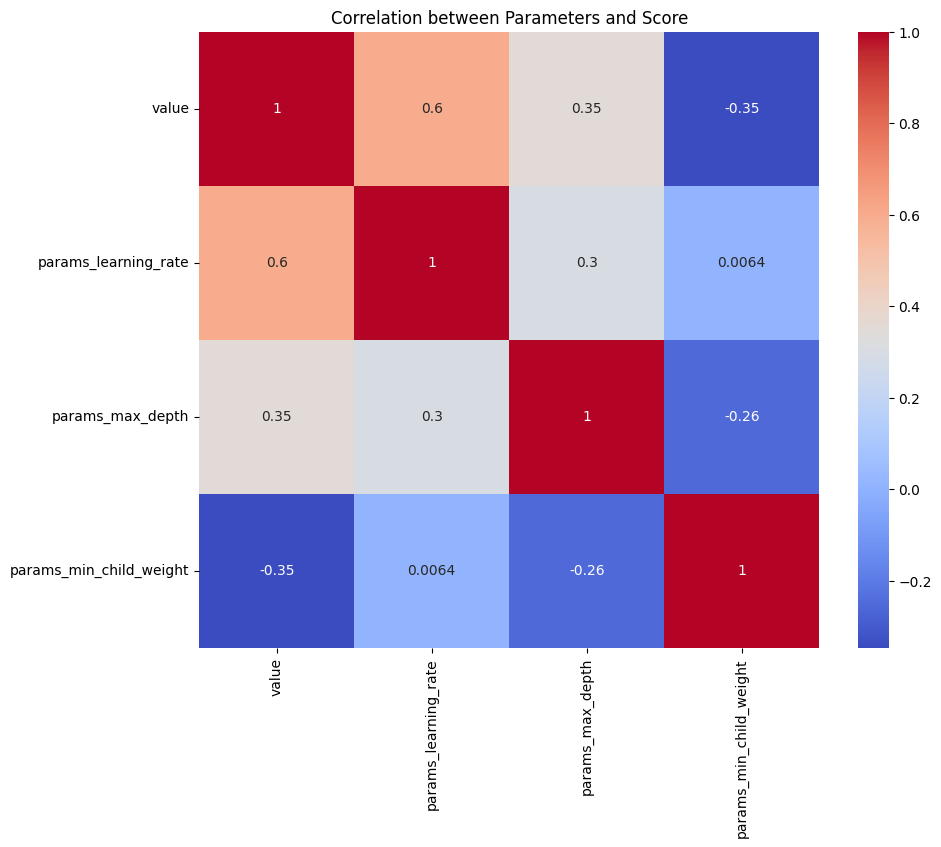

In [43]:
# Create a heatmap of parameter correlation
# This helps you see if parameters are fighting each other
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric parameter columns and the objective value
param_cols = [c for c in df.columns if 'params_' in c and df[c].dtype in [np.float64, np.int64]]
cols_to_plot = ['value'] + param_cols

plt.figure(figsize=(10,8))
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Parameters and Score")
plt.show()